In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

## Load Data

In [3]:
df = pd.read_csv('dataset/credit_risk_dataset.csv')
print('Shape: ', df.shape)
df.head()

Shape:  (32581, 30)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_term_months,employment_type,education_level,marital_status,num_dependents,credit_score,credit_utilization_pct,num_open_accounts,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,60,Full-time,NaN,Single,0.0,619.0,21.0,2.0,1.0,4.0,331.0,6490.0,0,4916.67,851.50,16090.24,0.241,0.136
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,24,Contract,High School,Single,1.0,639.0,13.8,4.0,1.0,1.0,91.0,3004.0,0,800.00,46.67,120.15,0.172,0.095
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,60,Self-employed,Diploma,Single,0.0,NaN,26.7,3.0,0.0,NaN,235.0,0.0,0,800.00,124.78,1986.57,0.450,0.120
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,60,Full-time,Doctorate,Single,0.0,706.0,31.5,4.0,1.0,0.0,1171.0,7516.0,0,5458.33,836.88,15212.74,0.368,0.087
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,36,Full-time,Doctorate,Single,0.0,607.0,NaN,3.0,3.0,1.0,522.0,2538.0,0,4533.33,1200.81,8229.23,0.380,0.167


## Understand structure and Types

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_home_ownership        32581 non-null  str    
 3   person_emp_length            31686 non-null  float64
 4   loan_intent                  32581 non-null  str    
 5   loan_grade                   32581 non-null  str    
 6   loan_amnt                    32581 non-null  int64  
 7   loan_int_rate                29465 non-null  float64
 8   loan_status                  32581 non-null  int64  
 9   loan_percent_income          32581 non-null  float64
 10  cb_person_default_on_file    32581 non-null  str    
 11  cb_person_cred_hist_length   32581 non-null  int64  
 12  loan_term_months             32581 non-null  int64  
 13  employment_type            

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.000,23.000,26.000,30.000,1.440000e+02
person_income,32581.0,66074.848470,61983.119168,4000.000,38500.000,55000.000,79200.000,6.000000e+06
person_emp_length,31686.0,4.789686,4.142630,0.000,2.000,4.000,7.000,1.230000e+02
loan_amnt,32581.0,9589.371106,6322.086646,500.000,5000.000,8000.000,12200.000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420,7.900,10.990,13.470,2.322000e+01
loan_status,32581.0,0.218164,0.413006,0.000,0.000,0.000,0.000,1.000000e+00
loan_percent_income,32581.0,0.170203,0.106782,0.000,0.090,0.150,0.230,8.300000e-01
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.000,3.000,4.000,8.000,3.000000e+01
loan_term_months,32581.0,42.193548,14.220175,12.000,36.000,36.000,60.000,6.000000e+01
num_dependents,31684.0,0.272630,0.616735,0.000,0.000,0.000,0.000,5.000000e+00


In [6]:
df.describe(include='object').T

C:\Users\pasan\AppData\Local\Temp\ipykernel_17836\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836
employment_type,31685,6,Full-time,20055
education_level,30686,5,Bachelor,11661
marital_status,31977,4,Single,19646


## Check missing values

In [7]:
missing = df.isna().sum()
missing_pct = (missing/len(df)*100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count>0')

,missing_count,missing_pct
person_emp_length,895,2.75
loan_int_rate,3116,9.56
employment_type,896,2.75
education_level,1895,5.82
marital_status,604,1.85
num_dependents,897,2.75
credit_score,1296,3.98
credit_utilization_pct,972,2.98
num_open_accounts,644,1.98
num_late_payments_24m,979,3.00


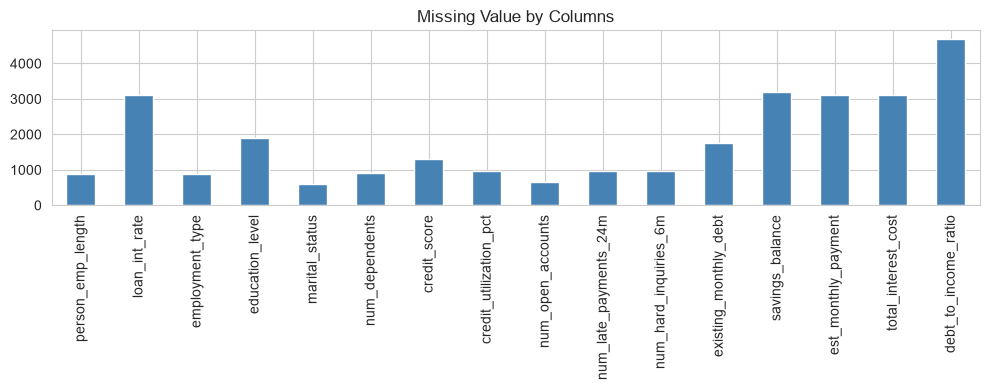

In [8]:
missing[missing>0].plot(kind='bar', color='steelblue', figsize=(10,4))
plt.title('Missing Value by Columns')
plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()

## Check for duplicates

In [9]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)")
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)

Fully duplicated rows: 165 (0.51%)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_term_months,employment_type,education_level,marital_status,num_dependents,credit_score,credit_utilization_pct,num_open_accounts,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2,24,Self-employed,High School,Single,0.0,496.0,72.4,2.0,1.0,1.0,161.0,235.0,0,674.0,58.32,199.56,0.325,0.095
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2,24,Self-employed,High School,Single,0.0,496.0,72.4,2.0,1.0,1.0,161.0,235.0,0,674.0,58.32,199.56,0.325,0.095
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4,36,Full-time,Diploma,Single,0.0,672.0,30.4,3.0,0.0,0.0,90.0,0.0,0,1300.0,86.97,330.88,0.136,0.190
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4,36,Full-time,Diploma,Single,0.0,672.0,30.4,3.0,0.0,0.0,90.0,0.0,0,1300.0,86.97,330.88,0.136,0.190
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2,60,Full-time,Diploma,Single,0.0,687.0,48.2,1.0,0.0,1.0,0.0,3371.0,0,1500.0,60.69,641.14,0.040,0.095
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2,60,Full-time,Diploma,Single,0.0,687.0,48.2,1.0,0.0,1.0,0.0,3371.0,0,1500.0,60.69,641.14,0.040,0.095


## Check for outliers

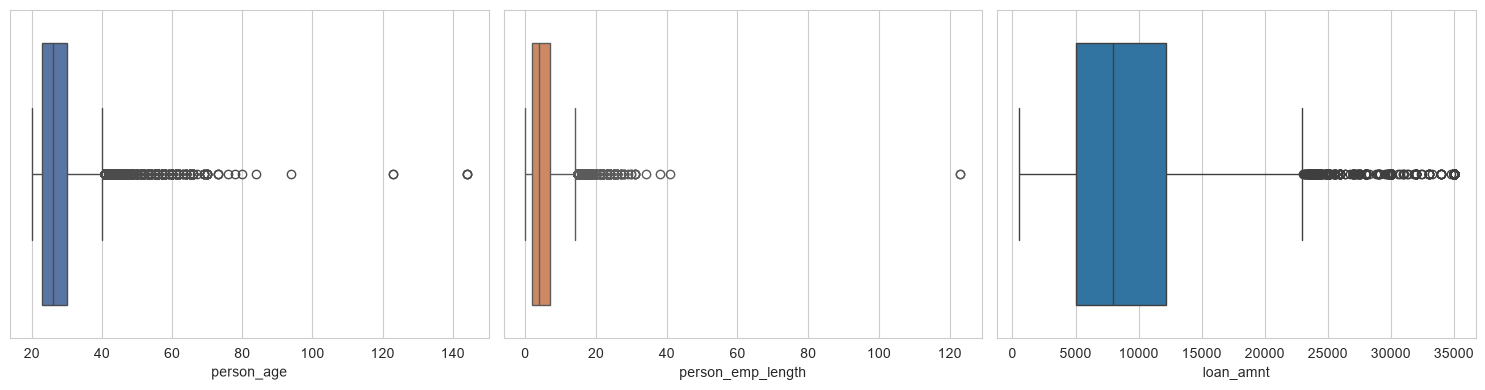

Records with person_age > 100: 5 | max age: 144
Records with person_emp_length > 60: 2 | max emp_length: 123.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df['person_age'], ax=axes[0], color='#4C72B0')
sns.boxplot(x=df['person_emp_length'], ax=axes[1], color='#DD8452')
sns.boxplot(x=df['loan_amnt'], ax=axes[2])
plt.tight_layout()
plt.savefig('outliers_boxplots.png')
plt.show()

print("Records with person_age > 100:", (df['person_age'] > 100).sum(), "| max age:", df['person_age'].max())
print("Records with person_emp_length > 60:", (df['person_emp_length'] > 60).sum(), "| max emp_length:", df['person_emp_length'].max())

## Check class imbalance

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.2
1    21.8
Name: count, dtype: float64


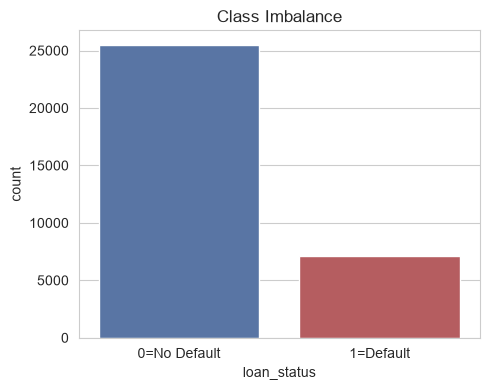

In [11]:
counts = df.loan_status.value_counts().sort_index()
pct = (counts/len(df)*100).round(1)
print(counts)
print(pct)

plt.figure(figsize=(5, 4))
sns.countplot(x='loan_status', data=df, hue='loan_status', palette=['#4C72B0', '#C44E52'], legend=False)
plt.xticks([0, 1], ['0=No Default', '1=Default'])
plt.title('Class Imbalance')
plt.tight_layout()
plt.savefig('class_imbalance.png')
plt.show()

## Look at distributions (numeric)

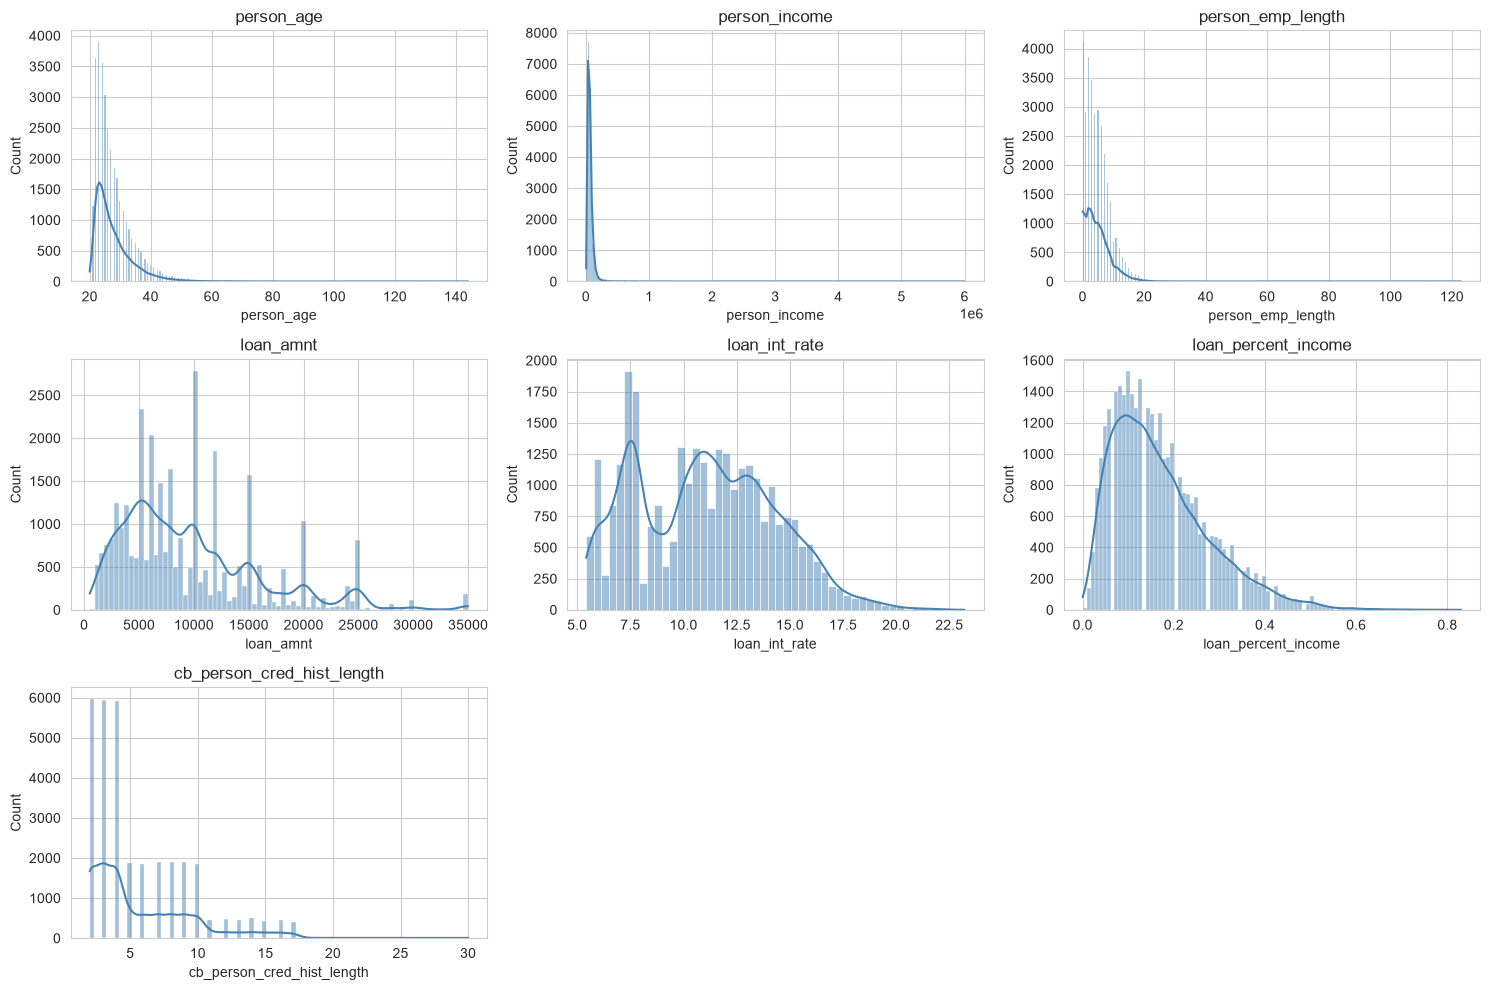

In [12]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(x=col, data=df, ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

## Categorical distributions

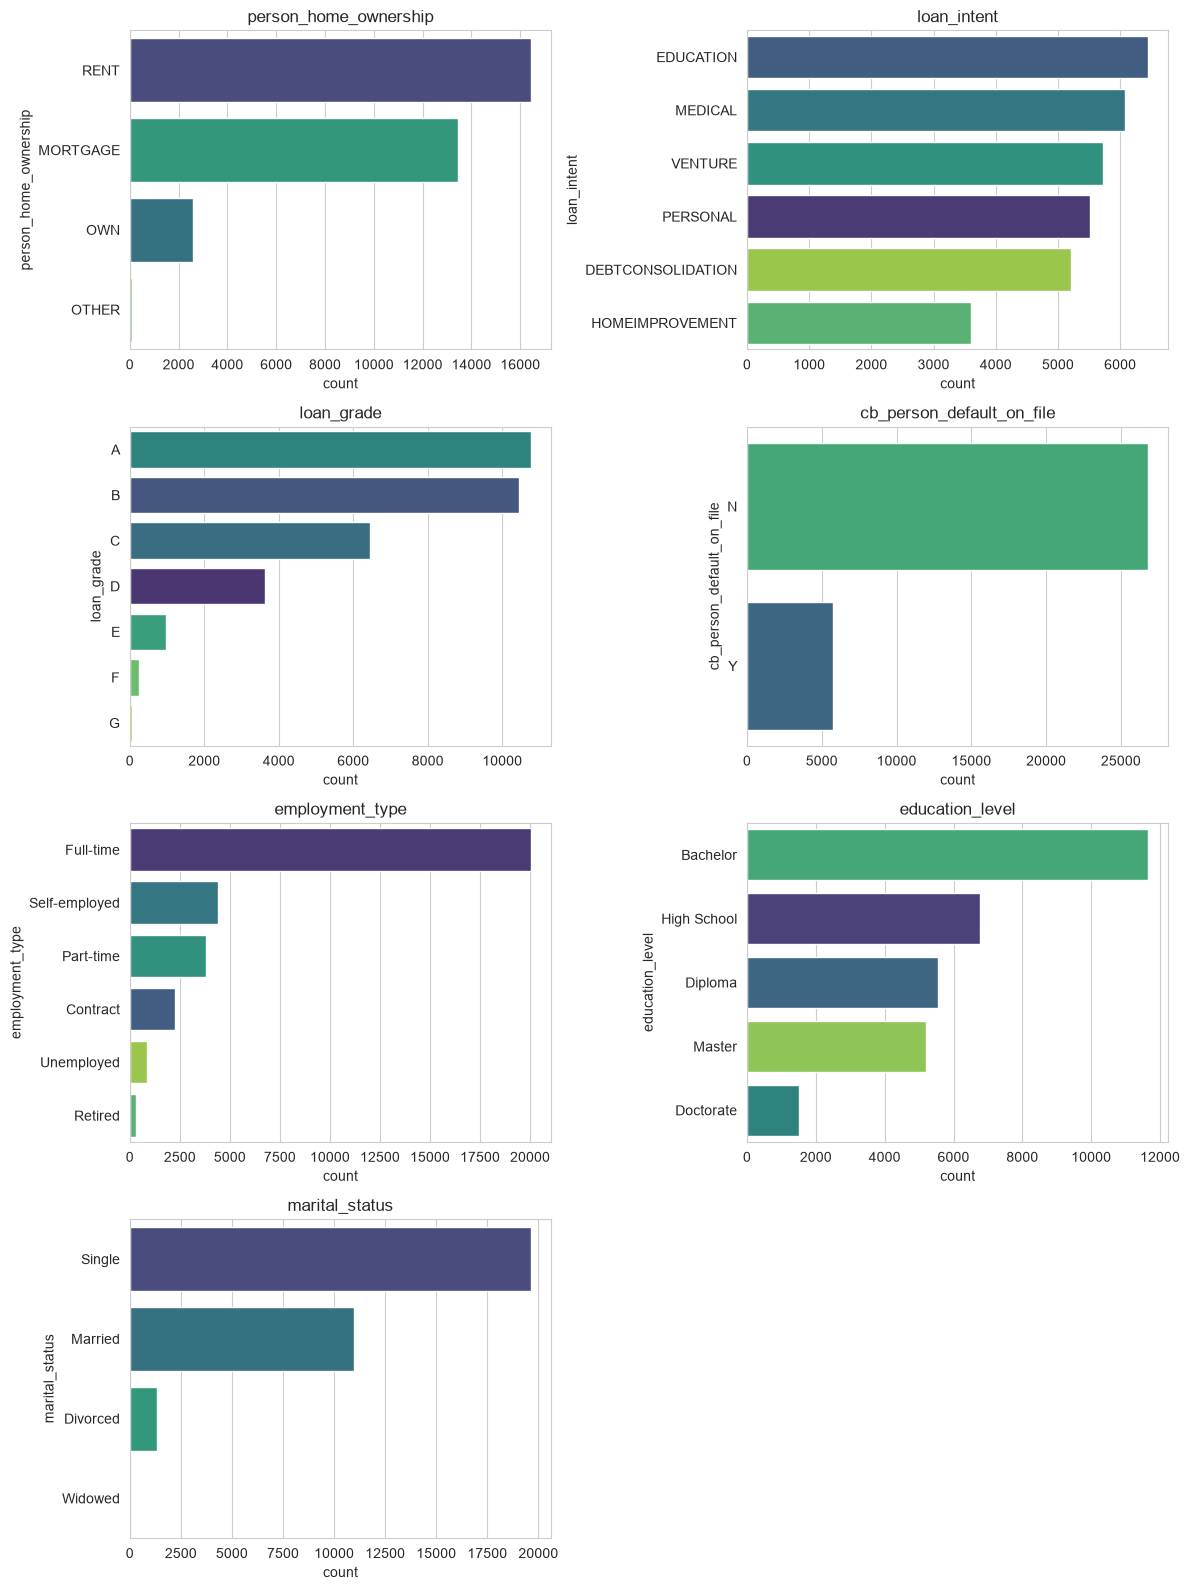

In [13]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file',
            'employment_type', 'education_level', 'marital_status']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, hue=col, data=df, order=order, ax=ax, palette='viridis', legend=False)
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig('categorical_distributions.png')
plt.show()

## Relationships with the target

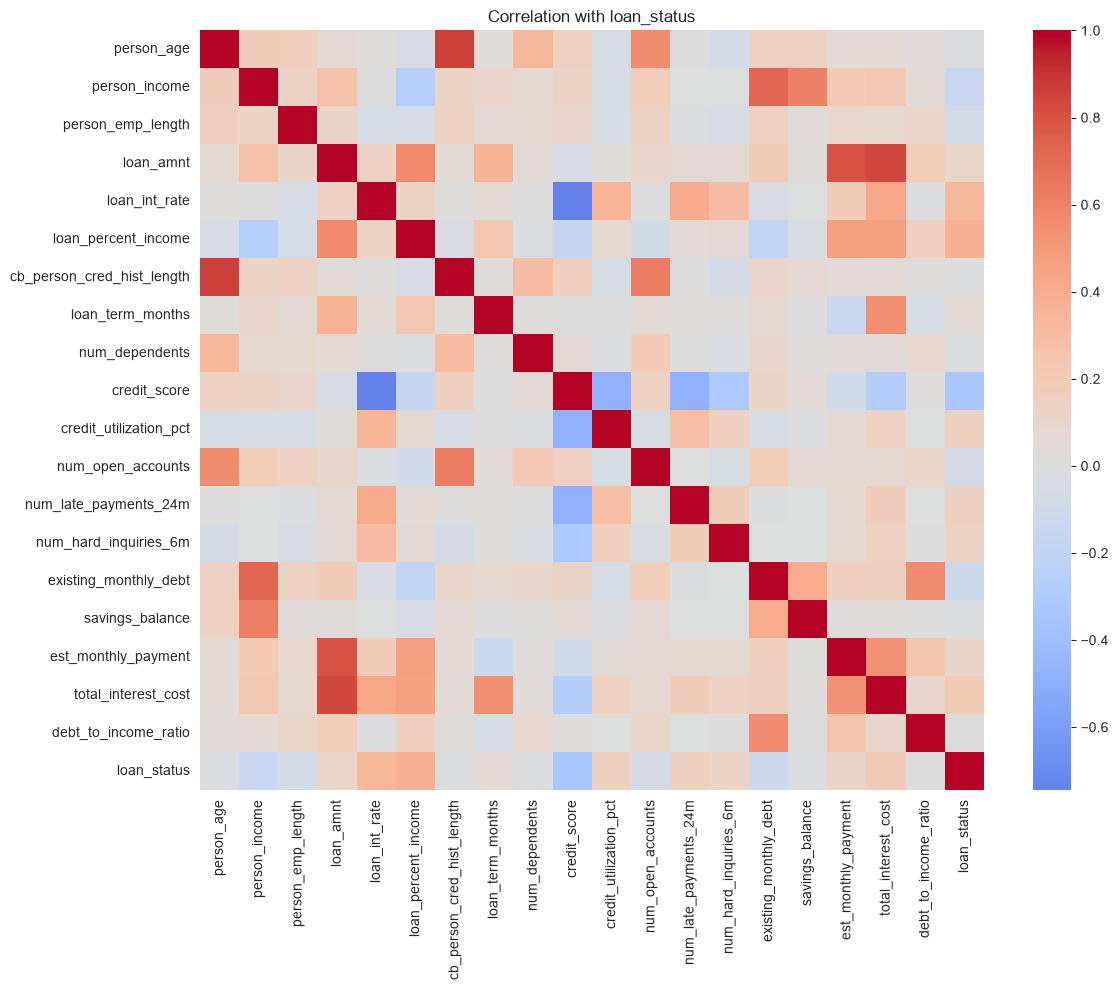

loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.335133
total_interest_cost           0.195975
credit_utilization_pct        0.154077
num_late_payments_24m         0.153036
num_hard_inquiries_6m         0.117229
est_monthly_payment           0.108649
loan_amnt                     0.105376
loan_term_months              0.043421
debt_to_income_ratio          0.004620
cb_person_cred_hist_length   -0.015529
num_dependents               -0.015550
savings_balance              -0.020656
person_age                   -0.021629
num_open_accounts            -0.067679
person_emp_length            -0.082489
existing_monthly_debt        -0.123278
person_income                -0.144449
credit_score                 -0.342640
Name: loan_status, dtype: float64


In [14]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate',
                'loan_percent_income', 'cb_person_cred_hist_length', 'loan_term_months', 'num_dependents',
                'credit_score', 'credit_utilization_pct', 'num_open_accounts', 'num_late_payments_24m',
                'num_hard_inquiries_6m', 'existing_monthly_debt', 'savings_balance', 'est_monthly_payment',
                'total_interest_cost', 'debt_to_income_ratio']

corr = df[numeric_cols + ['loan_status']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation with loan_status')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print(corr['loan_status'].sort_values(ascending=False))

## Preprocessing — remove duplicates

In [15]:
before = df.shape[0]
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} duplicate rows -> {df_clean.shape[0]} rows remaining")

Dropped 165 duplicate rows -> 32416 rows remaining


## Handle outliers

In [16]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean.person_age <= 100].reset_index(drop=True)
df_clean = df_clean[df_clean.person_emp_length <= 60].reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} invalid-outlier rows -> {df_clean.shape[0]} rows remaining")

Dropped 894 invalid-outlier rows -> 31522 rows remaining


## Handle missing values


In [17]:
before = df_clean.shape[0]

# --- numeric columns: grade-aware or median imputation ---
grade_median_rate = df_clean.groupby('loan_grade')['loan_int_rate'].transform('median')
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(grade_median_rate)
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())

numeric_impute_median = [
    'num_dependents', 'credit_score', 'credit_utilization_pct', 'num_open_accounts',
    'num_late_payments_24m', 'num_hard_inquiries_6m', 'existing_monthly_debt',
    'savings_balance', 'est_monthly_payment', 'total_interest_cost', 'debt_to_income_ratio'
]
for col in numeric_impute_median:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- categorical columns: fill with 'Unknown' rather than dropping the row ---
categorical_impute_unknown = ['employment_type', 'education_level', 'marital_status']
for col in categorical_impute_unknown:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# safety net only — should be 0 rows now; if not, inspect before dropping
remaining_missing = df_clean.isna().sum().sum()
print(f"Remaining missing values after imputation: {remaining_missing}")
if remaining_missing > 0:
    before_final = df_clean.shape[0]
    df_clean = df_clean.dropna().reset_index(drop=True)
    print(f"Dropped {before_final - df_clean.shape[0]} rows with leftover missing values -> {df_clean.shape[0]} rows remaining")
else:
    print(f"No rows dropped for missing values -> {df_clean.shape[0]} rows remaining")

print(f"Total rows dropped in this step: {before - df_clean.shape[0]}")

Remaining missing values after imputation: 0
No rows dropped for missing values -> 31522 rows remaining
Total rows dropped in this step: 0


## Feature engineering

In [18]:
df_clean['income_to_loan_ratio'] = (df_clean['person_income'] / df_clean['loan_amnt']).round(2)
df_clean['credit_history_to_age_ratio'] = (df_clean['cb_person_cred_hist_length'] / df_clean['person_age']).round(3)
df_clean['log_income'] = np.log1p(df_clean['person_income'])

## Encode categorical variables

In [19]:
grade_order = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
enc = OrdinalEncoder(categories=grade_order)
df_clean['loan_grade_encoded'] = enc.fit_transform(df_clean[['loan_grade']])

df_clean['cb_person_default_on_file'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)

nominal_cols = [c for c in ['person_home_ownership', 'loan_intent', 'employment_type',
                             'education_level', 'marital_status'] if c in df_clean.columns]
df_model = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# drop the original text-grade column now that loan_grade_encoded exists, to avoid duplicate info
df_model = df_model.drop(columns=['loan_grade'])
df_model.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_term_months,num_dependents,credit_score,credit_utilization_pct,num_open_accounts,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio,income_to_loan_ratio,log_income,loan_grade_encoded,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,employment_type_Full-time,employment_type_Part-time,employment_type_Retired,employment_type_Self-employed,employment_type_Unemployed,employment_type_Unknown,education_level_Diploma,education_level_Doctorate,education_level_High School,education_level_Master,education_level_Unknown,marital_status_Married,marital_status_Single,marital_status_Unknown,marital_status_Widowed
0,21,9600,5.0,1000,11.14,0,0.10,0,2,24,1.0,639.0,13.8,4.0,1.0,1.0,91.0,3004.0,0,800.00,46.67,120.15,0.172,0.095,9.60,9.169623,1.0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
1,25,9600,1.0,5500,12.87,1,0.57,0,3,60,0.0,691.0,26.7,3.0,0.0,1.0,235.0,0.0,0,800.00,124.78,1986.57,0.450,0.120,1.75,9.169623,2.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False
2,23,65500,4.0,35000,15.23,1,0.53,0,2,60,0.0,706.0,31.5,4.0,1.0,0.0,1171.0,7516.0,0,5458.33,836.88,15212.74,0.368,0.087,1.87,11.089821,2.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,24,54400,8.0,35000,14.27,1,0.55,1,4,36,0.0,607.0,28.0,3.0,3.0,1.0,522.0,2538.0,0,4533.33,1200.81,8229.23,0.380,0.167,1.55,10.904138,2.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,21,9900,2.0,2500,7.14,1,0.25,0,2,60,0.0,688.0,28.0,3.0,0.0,0.0,88.0,7356.0,0,825.00,49.67,480.10,0.167,0.095,3.96,9.200391,0.0,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False


## Remove leaking columns


In [20]:
leakage_cols = ['loan_grade_encoded', 'loan_int_rate']

X = df_model.drop(columns=['loan_status'] + leakage_cols)
y = df_model['loan_status']

print("Leakage-safe feature set:", X.shape)
print("Columns removed for leakage:", leakage_cols)
assert not any(c in X.columns for c in leakage_cols), "Leakage columns still present!"


Leakage-safe feature set: (31522, 47)
Columns removed for leakage: ['loan_grade_encoded', 'loan_int_rate']


## Feature selection


In [21]:
ratio_corr = X[['income_to_loan_ratio', 'loan_percent_income']].corr().iloc[0, 1]
print(f"Correlation between income_to_loan_ratio and loan_percent_income: {ratio_corr:.3f}")

if abs(ratio_corr) > 0.8:
    X = X.drop(columns=['income_to_loan_ratio'])
    print("Dropped 'income_to_loan_ratio' — redundant with 'loan_percent_income' (kept, since it's the original column).")
else:
    print("Correlation not high enough to justify dropping either column — both kept.")

print("Final feature set shape:", X.shape)

Correlation between income_to_loan_ratio and loan_percent_income: -0.458
Correlation not high enough to justify dropping either column — both kept.
Final feature set shape: (31522, 47)


## Train/test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

assert X_train.select_dtypes(include='object').empty
print("All columns numeric — safe to scale.")

X_train: (25217, 47)  X_test: (6305, 47)
Train class balance:
 loan_status
0    0.784
1    0.216
Name: proportion, dtype: float64
Test class balance:
 loan_status
0    0.784
1    0.216
Name: proportion, dtype: float64
All columns numeric — safe to scale.


## Scale numeric features

In [23]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

Handle Class Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE — class balance in training set:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE — class balance in training set:")
print(y_train_balanced.value_counts())

X_train_balanced.to_csv('dataset/X_train_balanced.csv', index=False)
y_train_balanced.to_csv('dataset/y_train_balanced.csv', index=False)
print("\nSaved: dataset/X_train_balanced.csv, dataset/y_train_balanced.csv")

   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/236.1 kB ? eta -:--:--
   ----- --------------------------------- 30.7/236.1 kB 640.0 kB/s eta 0:00:01
   ----- --------------------------------- 30.7/236.1 kB 640.0 kB/s eta 0:00:01
   ----- --------------------------------- 30.7/236.1 kB 640.0 kB/s eta 0:00:01
   ----- --------------------------------- 30.7/236.1 kB 640.0 kB/s eta 0:00:01
   ---------- ---------------------------- 61.4/236.1 kB 217.9 kB/s eta 0:00:01
   ----------- --------------------------- 71.7/236.1 kB 231.0 kB/s eta 0:00:01
   ----------- --------------------------- 71.7/236.1 kB 231.0 kB/s eta 0:00:01
   --------------- ----------------------- 92.2/236.1 kB 238.1 kB/s eta 0:00:01
   --------------- ----------------------- 92.2/236.1 kB 238.1 kB/s eta 0:00:01
   ------------------ ------------------- 112.6/236.1 kB 233.8 kB/


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Before SMOTE — class balance in training set:
loan_status
0    19772
1     5445
Name: count, dtype: int64

After SMOTE — class balance in training set:
loan_status
0    19772
1    19772
Name: count, dtype: int64

Saved: X_train_balanced.csv, y_train_balanced.csv


In [ ]:
X_train_scaled.to_csv('dataset/X_train.csv', index=False)
X_test_scaled.to_csv('dataset/X_test.csv', index=False)
y_train.to_csv('dataset/y_train.csv', index=False)
y_test.to_csv('dataset/y_test.csv', index=False)

print("Saved: dataset/X_train.csv, dataset/X_test.csv, dataset/y_train.csv, dataset/y_test.csv")

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
